# Phase 2: Feature Selection + Neural Network

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
sys.path.insert(0, os.path.abspath('..'))

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

RESULTS_DIR = '../phase2_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Data Preprocess

In [3]:
from student_project import load_data, preprocess_data, train_gb_pipeline, RandomForest as RF_phase1

df_original = load_data('../datasets/student-mat.csv')
print(f'Data Shape: {df_original.shape}')
df_original.head()

Data Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df = preprocess_data(df_original)

feature_names = [c for c in df.columns if c != 'at_risk']
X = df[feature_names].values.astype(np.float32)
y = df['at_risk'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y)
print(f'Training: {X_train.shape[0]}')
print(f'Testing: {X_test.shape[0]}')

# Check data is biased
print(f'at_risk (train): {int(y_train.sum())} | {len(y_train)} ({y_train.mean():.1%})')
print(f'at_risk (test): {int(y_test.sum())} | {len(y_test)} ({y_test.mean():.1%})')

Training: 296
Testing: 99
at_risk (train): 97 | 296 (32.8%)
at_risk (test): 33 | 99 (33.3%)


## 2. Feature Selection
### Referneces: 
https://www.geeksforgeeks.org/machine-learning/feature-selection-techniques-in-machine-learning/

https://www.geeksforgeeks.org/machine-learning/variance-threshold/

https://www.geeksforgeeks.org/maths/pearson-correlation-coefficient/

### 2.1. Variance

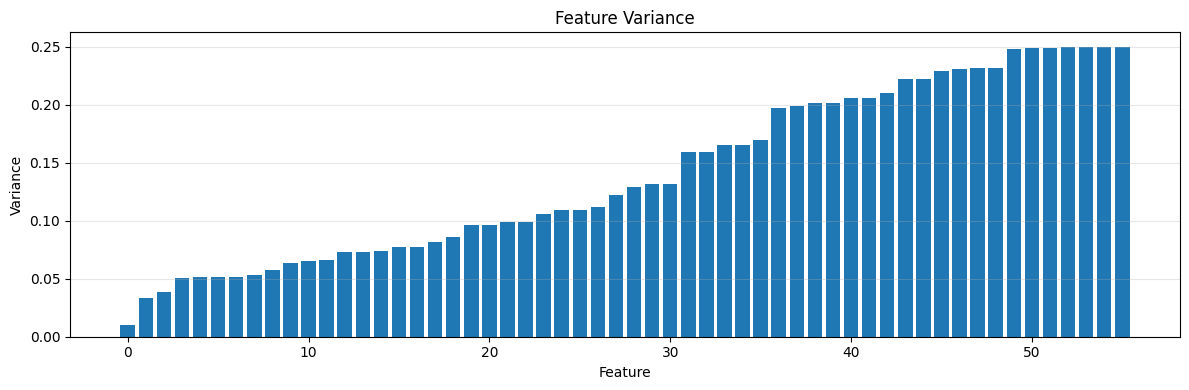

In [5]:
feature_variances = np.var(X_train, axis=0)
variance_sorted_idx = np.argsort(feature_variances)

plt.figure(figsize=(12, 4))
plt.bar(range(len(feature_variances)), feature_variances[variance_sorted_idx])
plt.xlabel('Feature')
plt.ylabel('Variance')
plt.title('Feature Variance')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/variance.png')
plt.show()

### 2.2. Pearson Correlation

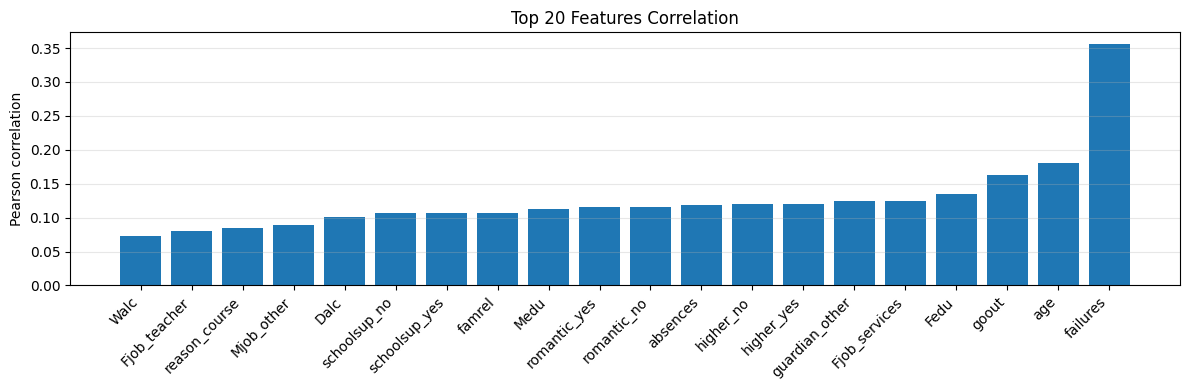

In [6]:
corr_matrix = np.corrcoef(X_train.T, y_train)
abs_correlations = np.abs(corr_matrix[:-1, -1])

top_num = 20
top_idx = np.argsort(abs_correlations)[-top_num:]
plt.figure(figsize=(12, 4))
plt.bar(range(top_num), abs_correlations[top_idx])
plt.xticks(range(top_num), [feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.ylabel('Pearson correlation')
plt.title(f'Top {top_num} Features Correlation')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_correlation.png')
plt.show()

### 2.3. Find best K

K= 5  F1=0.231  AUC=0.534
K=10  F1=0.500  AUC=0.587
K=15  F1=0.517  AUC=0.676
K=20  F1=0.509  AUC=0.645
K=25  F1=0.491  AUC=0.692
K=30  F1=0.444  AUC=0.687


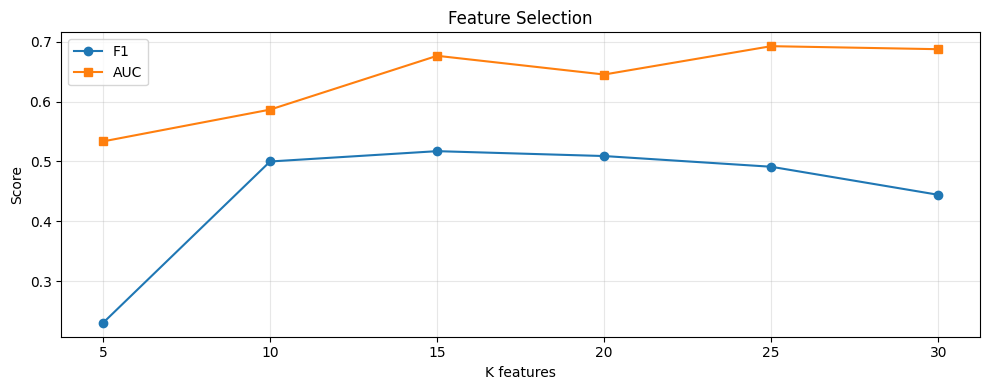

In [7]:
rank_order = np.argsort(abs_correlations)[::-1]
gb = GradientBoostingClassifier(random_state=RANDOM_SEED)

k_values = [5, 10, 15, 20, 25, 30]
f1_scores, auc_scores = [], []
for k in k_values:
    gb.fit(X_train[:, rank_order[:k]], y_train)
    proba = gb.predict_proba(X_test[:, rank_order[:k]])[:, 1]
    preds = (proba >= 0.5).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    auc_scores.append(roc_auc_score(y_test, proba))
    print(f'K={k:2d}  F1={f1_scores[-1]:.3f}  AUC={auc_scores[-1]:.3f}')

plt.figure(figsize=(10, 4))
plt.plot(k_values, f1_scores, marker='o', label='F1')
plt.plot(k_values, auc_scores, marker='s', label='AUC')
plt.xlabel('K features')
plt.ylabel('Score')
plt.title('Feature Selection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_selection.png')
plt.show()

In [8]:
# best_k = k_values[np.argmax(auc_scores)]
best_k = 15
selected_idx = rank_order[:best_k]
selected_features = [feature_names[i] for i in selected_idx]

X_train_sel = X_train[:, selected_idx]
X_test_sel = X_test[:, selected_idx]

print(f'Best K={best_k}')
print('Selected features:', selected_features)

Best K=15
Selected features: ['failures', 'age', 'goout', 'Fedu', 'Fjob_services', 'guardian_other', 'higher_yes', 'higher_no', 'absences', 'romantic_no', 'romantic_yes', 'Medu', 'famrel', 'schoolsup_yes', 'schoolsup_no']


## Neural Network
### Referneces: 
https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html

In [9]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            # Fixed[2026.04.18]: Change to 2 layers, higher dropout rate
            # Layer 1
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),

            # Layer 2
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [10]:
def train_mlp(X_train, y_train, X_test, y_test, lr=1e-3, epochs=30, patience=15):
    pos_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)], dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model = MLP(X_train.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    X_te_t = torch.tensor(X_test)
    y_te_t = torch.tensor(y_test)

    history = {'train_loss': [], 'val_loss': []}
    best_auc = 0
    best_state = None
    stop = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_te_t)
            val_loss = criterion(val_logits, y_te_t).item()
            val_proba = torch.sigmoid(val_logits).numpy()

        val_auc = roc_auc_score(y_test, val_proba)
        history['train_loss'].append(epoch_loss / len(X_train))
        history['val_loss'].append(val_loss)

        #Fixed[2026.04.19]: Early Stopping
        if val_auc > best_auc:
            best_auc  = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            stop = 0
        else:
            stop += 1
            if stop >= patience:
                break

    model.load_state_dict(best_state)
    return model, history


def eval_mlp(model, X, y):
    model.eval()
    with torch.no_grad():
        proba = torch.sigmoid(model(torch.tensor(X))).numpy()
    preds = (proba >= 0.5).astype(int)
    return {
        'f1': f1_score(y, preds, zero_division=0),
        'auc': roc_auc_score(y, proba),
        'proba': proba,
        'preds': preds
    }

all features: F1=0.525; AUC=0.671
top 15 features: F1=0.545; AUC=0.704


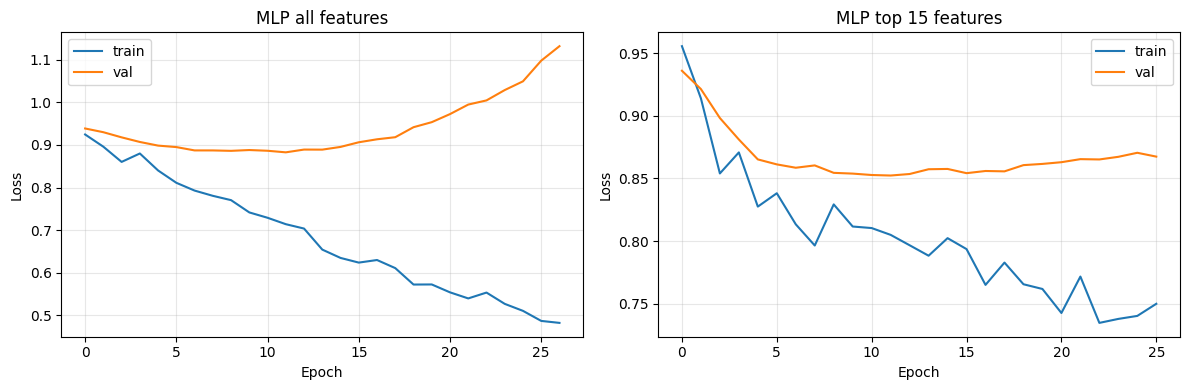

In [11]:
mlp_all, hist_all = train_mlp(X_train, y_train, X_test, y_test)
mlp_all_metrics = eval_mlp(mlp_all, X_test, y_test)
print(f'all features: F1={mlp_all_metrics["f1"]:.3f}; AUC={mlp_all_metrics["auc"]:.3f}')

mlp_sel, hist_sel = train_mlp(X_train_sel, y_train, X_test_sel, y_test)
mlp_sel_metrics = eval_mlp(mlp_sel, X_test_sel, y_test)
print(f'top {best_k} features: F1={mlp_sel_metrics["f1"]:.3f}; AUC={mlp_sel_metrics["auc"]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, title in zip(axes, [hist_all, hist_sel], ['all features', f'top {best_k} features']):
    ax.plot(hist['train_loss'], label='train')
    ax.plot(hist['val_loss'], label='val')
    ax.set_title(f'MLP {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/mlp_training.png')
plt.show()

## Results & Analysis

In [12]:
# Data
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

X_train_sel_df = pd.DataFrame(X_train_sel, columns=selected_features)
X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)

# GB
gb_all = train_gb_pipeline(X_train_df, y_train)
gb_all_preds = gb_all.predict(X_test_df)
gb_all_proba = gb_all.predict_proba(X_test_df)[:, 1]

gb_sel = train_gb_pipeline(X_train_sel_df, y_train)
gb_sel_preds = gb_sel.predict(X_test_sel_df)
gb_sel_proba = gb_sel.predict_proba(X_test_sel_df)[:, 1]

# RF
# Fixed[2026.04.18]: Set threshold based on biased data
rf_threshold = y_train.mean()

rf_all = RF_phase1(n_estimators=50, max_depth=16, sample_size=int(len(X_train) * 0.5), random_state=RANDOM_SEED)
rf_all.fit(X_train, y_train)
rf_all_proba = rf_all.predict_proba(X_test)
rf_all_preds = (rf_all_proba >= rf_threshold).astype(int)

rf_sel = RF_phase1(n_estimators=50, max_depth=16, sample_size=int(len(X_train_sel) * 0.5), random_state=RANDOM_SEED)
rf_sel.fit(X_train_sel, y_train)
rf_sel_proba = rf_sel.predict_proba(X_test_sel)
rf_sel_preds = (rf_sel_proba >= rf_threshold).astype(int)

In [13]:
sel = f'top {best_k}'

gb_all_f1 = f1_score(y_test, gb_all_preds, zero_division=0)
gb_all_auc = roc_auc_score(y_test, gb_all_proba)
gb_sel_f1 = f1_score(y_test, gb_sel_preds, zero_division=0)
gb_sel_auc = roc_auc_score(y_test, gb_sel_proba)
rf_all_f1 = f1_score(y_test, rf_all_preds, zero_division=0)
rf_all_auc = roc_auc_score(y_test, rf_all_proba)
rf_sel_f1 = f1_score(y_test, rf_sel_preds, zero_division=0)
rf_sel_auc = roc_auc_score(y_test, rf_sel_proba)

results = pd.DataFrame([
    ['GB', 'all', gb_all_f1, gb_all_auc],
    ['GB', sel, gb_sel_f1, gb_sel_auc],
    ['RF', 'all', rf_all_f1, rf_all_auc],
    ['RF', sel, rf_sel_f1, rf_sel_auc],
    ['MLP', 'all', mlp_all_metrics['f1'], mlp_all_metrics['auc']],
    ['MLP', sel, mlp_sel_metrics['f1'], mlp_sel_metrics['auc']],
], columns=['Model', 'Features', 'F1', 'AUC']).round(3)

print(results)

  Model Features     F1    AUC
0    GB      all  0.392  0.665
1    GB   top 15  0.517  0.677
2    RF      all  0.453  0.664
3    RF   top 15  0.356  0.687
4   MLP      all  0.525  0.671
5   MLP   top 15  0.545  0.704


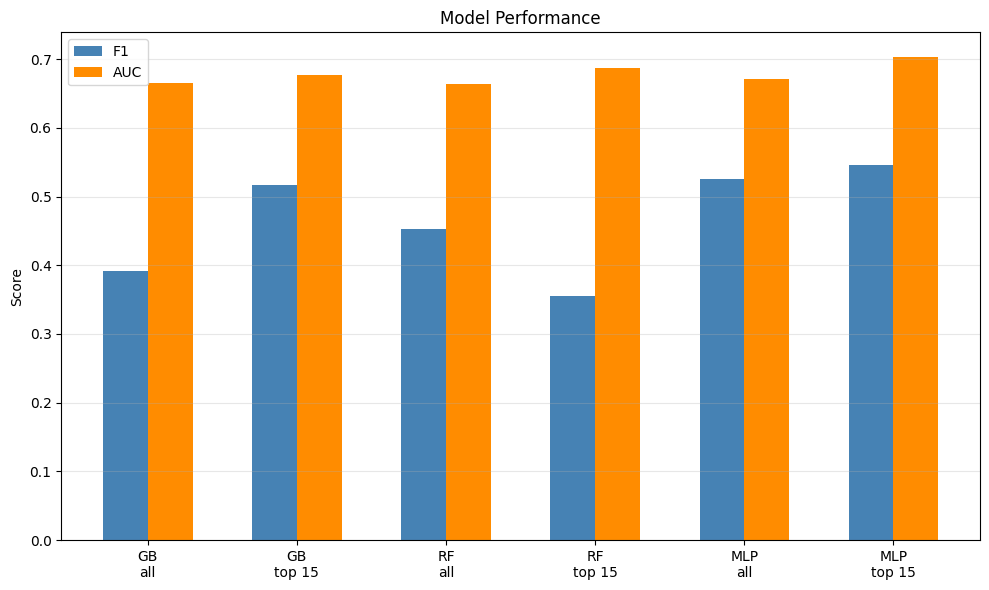

In [14]:
labels = ['GB\nall', f'GB\n{sel}', 'RF\nall', f'RF\n{sel}', 'MLP\nall', f'MLP\n{sel}']
all_f1 = [gb_all_f1, gb_sel_f1, rf_all_f1, rf_sel_f1, mlp_all_metrics['f1'], mlp_sel_metrics['f1']]
all_auc = [gb_all_auc, gb_sel_auc, rf_all_auc, rf_sel_auc, mlp_all_metrics['auc'], mlp_sel_metrics['auc']]

x = np.arange(len(labels))
x_shift = 0.3
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - x_shift/2, all_f1, x_shift, label='F1', color='steelblue')
ax.bar(x + x_shift/2, all_auc, x_shift, label='AUC', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_title('Model Performance')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_performance.png')
plt.show()